In [1]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
size_text =24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w = 10
h = 6

#  Dataset

In [3]:
df = pd.read_csv("factores_forma_uniformes_30000_R_0.1.csv")
X = df[["h", "k", "d"]].values
y = df["F"].values.reshape(-1, 1)

In [4]:
df.head()

,h,k,d,F
0,-50.0,-50.0,10,2.790539e-07
1,-50.0,-50.0,15,4.182728e-07
2,-50.0,-50.0,20,5.096276e-07
3,-50.0,-50.0,25,5.664967e-07
4,-50.0,-50.0,30,6.001080e-07


# Train - test Set

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [6]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

In [7]:
valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)
H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)

# Convert to tensors

In [8]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled.reshape(-1, 1), dtype=torch.float32)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl  = DataLoader(test_ds , batch_size=256, shuffle=False)

# Create neural network

In [9]:
class MLP(nn.Module):
    def __init__(self, in_dim: int = 3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()



# training the model

In [10]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def rmse(pred, target):
    return torch.sqrt(nn.functional.mse_loss(pred, target))

EPOCHS = 300
train_rmse_list = []
test_rmse_list = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()


    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train_tensor)
        rmse_train = rmse(y_pred_train, y_train_tensor).item()

        y_pred_test = model(X_test_tensor)
        rmse_test = rmse(y_pred_test, y_test_tensor).item()

    train_rmse_list.append(rmse_train)
    test_rmse_list.append(rmse_test)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | RMSE_train: {rmse_train:.4e} | RMSE_test: {rmse_test:.4e}")


Epoch   1 | RMSE_train: 1.7942e-01 | RMSE_test: 1.8107e-01
Epoch  20 | RMSE_train: 5.9041e-02 | RMSE_test: 6.2389e-02
Epoch  40 | RMSE_train: 3.2283e-02 | RMSE_test: 3.4571e-02
Epoch  60 | RMSE_train: 2.3901e-02 | RMSE_test: 2.5230e-02
Epoch  80 | RMSE_train: 2.1443e-02 | RMSE_test: 2.2469e-02
Epoch 100 | RMSE_train: 1.5728e-02 | RMSE_test: 1.6914e-02
Epoch 120 | RMSE_train: 1.2168e-02 | RMSE_test: 1.2570e-02
Epoch 140 | RMSE_train: 8.3629e-03 | RMSE_test: 8.7624e-03
Epoch 160 | RMSE_train: 5.9361e-03 | RMSE_test: 6.4216e-03
Epoch 180 | RMSE_train: 6.5432e-03 | RMSE_test: 6.7657e-03
Epoch 200 | RMSE_train: 6.8747e-03 | RMSE_test: 7.2274e-03
Epoch 220 | RMSE_train: 4.5400e-03 | RMSE_test: 4.6775e-03
Epoch 240 | RMSE_train: 1.3291e-02 | RMSE_test: 1.3947e-02
Epoch 260 | RMSE_train: 7.1133e-03 | RMSE_test: 7.6432e-03
Epoch 280 | RMSE_train: 6.3868e-03 | RMSE_test: 6.6237e-03
Epoch 300 | RMSE_train: 3.5385e-03 | RMSE_test: 3.7574e-03


# Measure execution times

In [ ]:
import time

model = MLP()

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def rmse(pred, target):
    return torch.sqrt(nn.functional.mse_loss(pred, target))

EPOCHS = 300
train_rmse_list = []
test_rmse_list = []

t0 = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train_tensor)
        rmse_train = rmse(y_pred_train, y_train_tensor).item()

        y_pred_test = model(X_test_tensor)
        rmse_test = rmse(y_pred_test, y_test_tensor).item()

    train_rmse_list.append(rmse_train)
    test_rmse_list.append(rmse_test)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | RMSE_train: {rmse_train:.4e} | RMSE_test: {rmse_test:.4e}")

t1 = time.perf_counter()
T_train_mlp = t1 - t0

model.eval()
with torch.no_grad():
    t2 = time.perf_counter()
    y_pred_test_final = model(X_test_tensor)
    t3 = time.perf_counter()

T_pred_mlp = t3 - t2
N_pred_mlp = X_test_tensor.shape[0]
t_pred_mlp = T_pred_mlp / N_pred_mlp

print(f"\nMLP training time: {T_train_mlp:.6f} s")
print(f"Total MLP prediction time (test set): {T_pred_mlp:.6f} s for {N_pred_mlp} samples")
print(f"MLP prediction time per sample: {t_pred_mlp:.8f} s/sample")

Epoch   1 | RMSE_train: 1.7170e-01 | RMSE_test: 1.7342e-01
Epoch  20 | RMSE_train: 3.9293e-02 | RMSE_test: 4.0778e-02
Epoch  40 | RMSE_train: 2.7579e-02 | RMSE_test: 2.8528e-02
Epoch  60 | RMSE_train: 1.5569e-02 | RMSE_test: 1.6196e-02
Epoch  80 | RMSE_train: 1.3516e-02 | RMSE_test: 1.4096e-02
Epoch 100 | RMSE_train: 1.1834e-02 | RMSE_test: 1.1927e-02
Epoch 120 | RMSE_train: 8.4573e-03 | RMSE_test: 8.8665e-03
Epoch 140 | RMSE_train: 8.7633e-03 | RMSE_test: 9.0701e-03
Epoch 160 | RMSE_train: 6.5916e-03 | RMSE_test: 7.1392e-03
Epoch 180 | RMSE_train: 5.1928e-03 | RMSE_test: 5.6857e-03
Epoch 200 | RMSE_train: 4.0598e-03 | RMSE_test: 4.3381e-03
Epoch 220 | RMSE_train: 8.3221e-03 | RMSE_test: 8.4141e-03
Epoch 240 | RMSE_train: 6.4296e-03 | RMSE_test: 6.6525e-03
Epoch 260 | RMSE_train: 4.9167e-03 | RMSE_test: 5.4519e-03
Epoch 280 | RMSE_train: 8.1551e-03 | RMSE_test: 8.4185e-03
Epoch 300 | RMSE_train: 6.4087e-03 | RMSE_test: 6.6549e-03

MLP training time: 173.540437 s
Total MLP prediction ti

# Learning curves

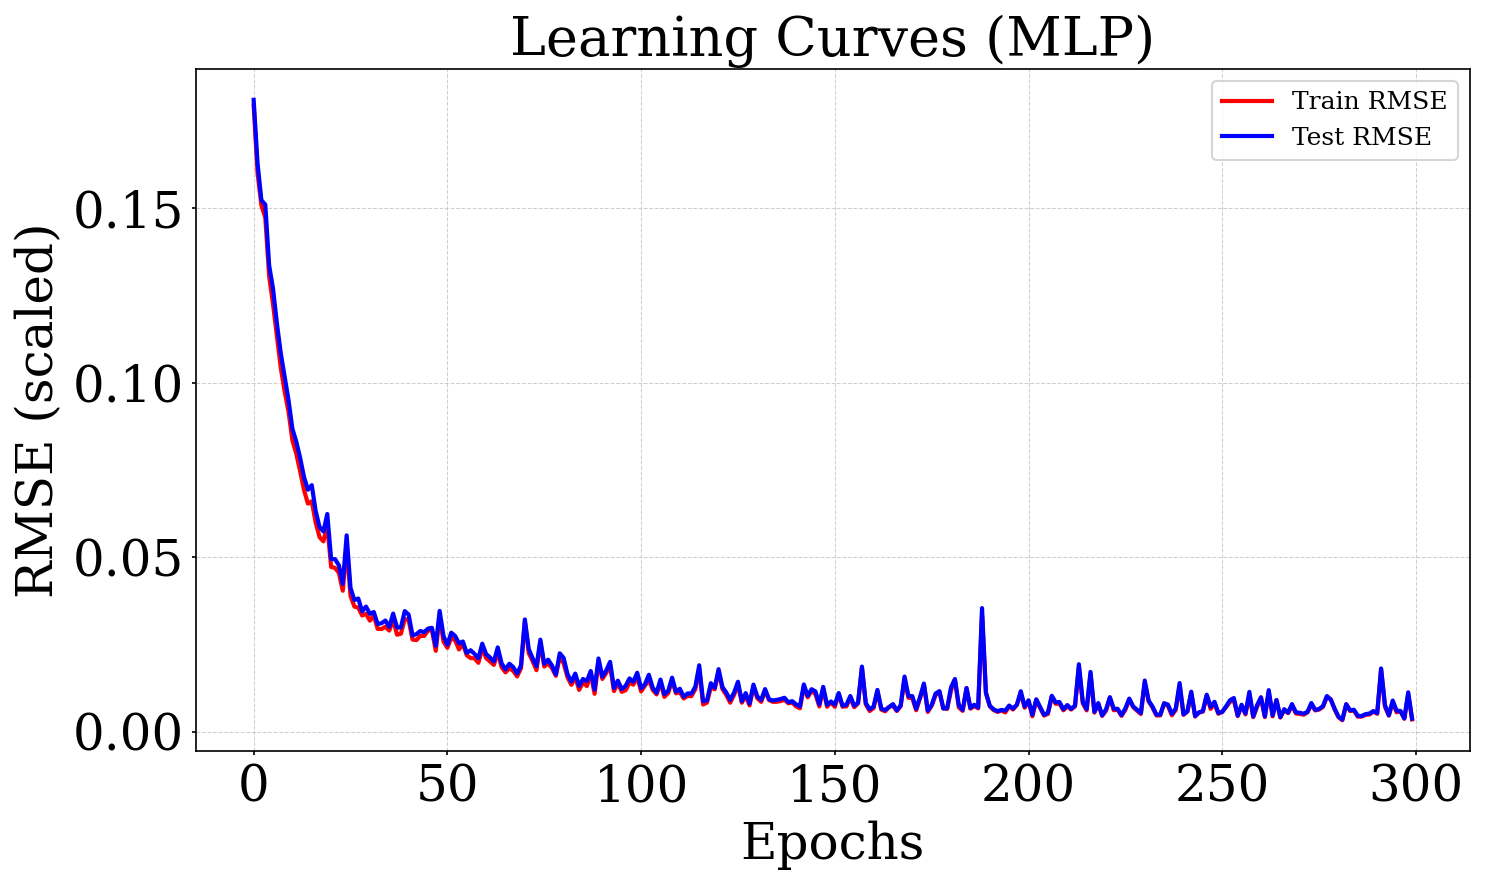

In [18]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)


ax.plot(train_rmse_list, "r-", linewidth=2, label="Train RMSE")
ax.plot(test_rmse_list, "b-", linewidth=2, label="Test RMSE")


ax.set_title("Learning Curves (MLP)", fontsize=size_text + 2)
ax.set_xlabel("Epochs", fontsize=size_text)
ax.set_ylabel("RMSE (scaled)", fontsize=size_text)


ax.legend(fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


plt.tight_layout()
plt.savefig("learning_curve_mlp_scaled.png", dpi=400, bbox_inches='tight')
plt.savefig("learning_curve_mlp_scaled.pdf", dpi=400, bbox_inches='tight')
plt.savefig("learning_curve_mlp_scaled.eps", dpi=400, bbox_inches='tight')

plt.show()

# Metrics

In [11]:
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).numpy()
    y_test_pred_scaled  = model(X_test_tensor).numpy()

# Desescalar
y_train_pred_real = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_test_pred_real  = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

y_train_real = scaler_y.inverse_transform(y_train_tensor.numpy().reshape(-1, 1))
y_test_real  = scaler_y.inverse_transform(y_test_tensor.numpy().reshape(-1, 1))

## Metrics of training

In [12]:
mse_train  = mean_squared_error(y_train_real, y_train_pred_real)
rmse_train = np.sqrt(mse_train)
mae_train  = mean_absolute_error(y_train_real, y_train_pred_real)
r2_train   = r2_score(y_train_real, y_train_pred_real)

print("ENTENAMIENTO:")
print(f"MSE:  {mse_train:.3e}")
print(f"RMSE: {rmse_train:.3e}")
print(f"MAE:  {mae_train:.3e}")
print(f"R²:   {r2_train:.8f}")

ENTENAMIENTO:
MSE:  7.676e-18
RMSE: 2.770e-09
MAE:  1.900e-09
R²:   0.99998748


## Metrics of testing

In [13]:
mse_test  = mean_squared_error(y_test_real, y_test_pred_real)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_real, y_test_pred_real)
r2_test   = r2_score(y_test_real, y_test_pred_real)

print("TEST:")
print(f"MSE:  {mse_test:.3e}")
print(f"RMSE: {rmse_test:.3e}")
print(f"MAE:  {mae_test:.3e}")
print(f"R²:   {r2_test:.8f}")

TEST:
MSE:  8.655e-18
RMSE: 2.942e-09
MAE:  1.944e-09
R²:   0.99998569


# Mape for training

In [14]:
mape_1 = np.mean(np.abs((y_train_real - y_train_pred_real) / y_train_real)) * 100
print(f" MAPE: {mape_1:.2f}%")

 MAPE: 0.16%


In [15]:
tolerance_1 = 0.05
percentage = np.mean(np.abs((y_train_real - y_train_pred_real) / y_train_real) < tolerance_1) * 100
print(f"Predicciones con <5% error: {percentage:.2f}%")

Predicciones con <5% error: 99.98%


# mape for testing

In [16]:
mape = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real)) * 100
print(f" MAPE: {mape:.2f}%")

 MAPE: 0.17%


In [17]:
tolerance = 0.05
percentage = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real) < tolerance) * 100
print(f"Predicciones con <5% error: {percentage:.2f}%")

Predicciones con <5% error: 99.95%


# Heatmap of predictions

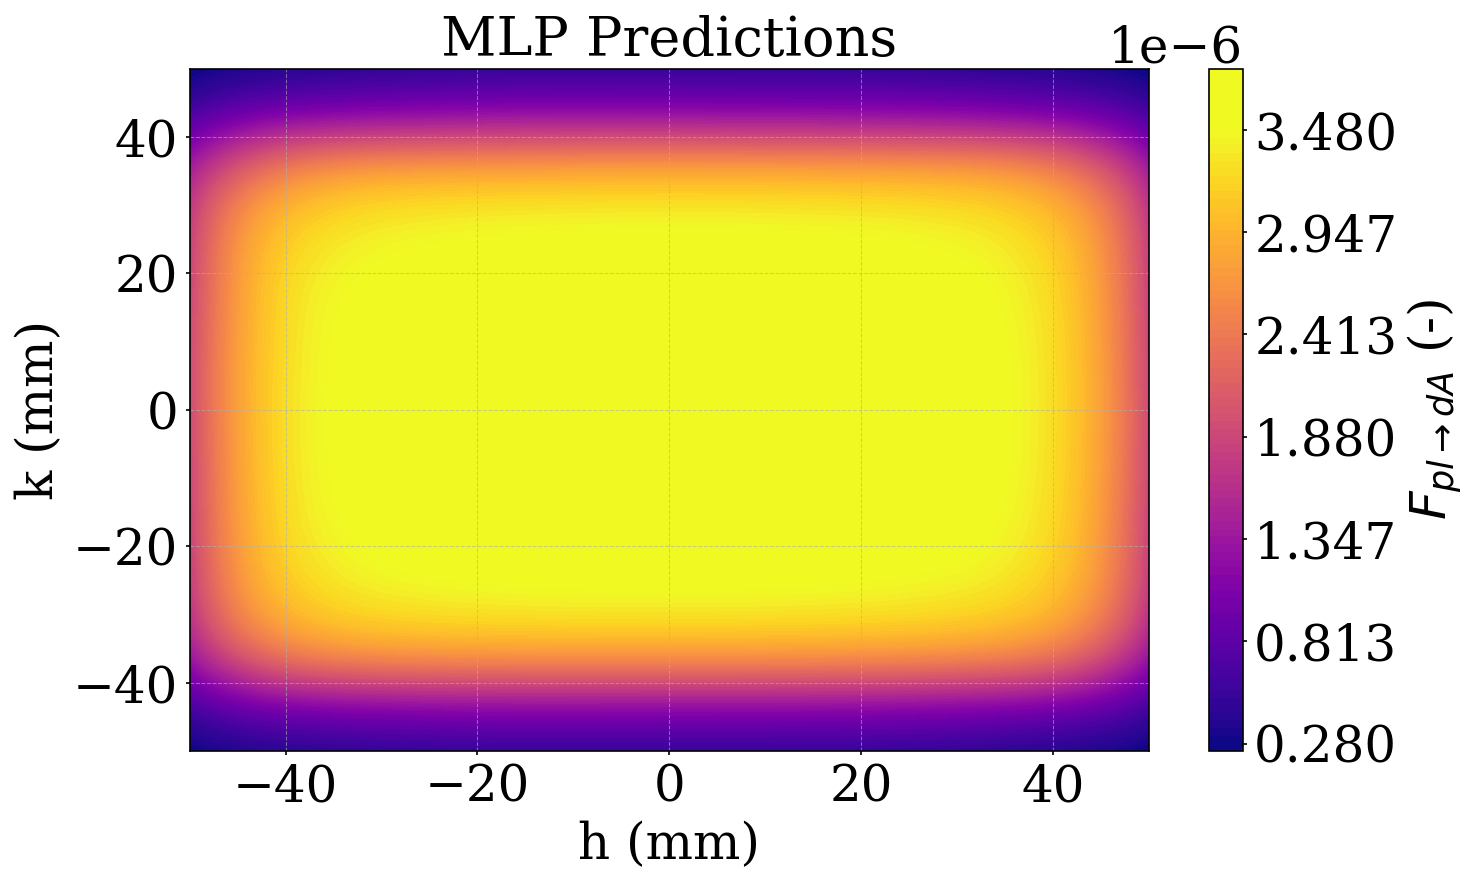

In [ ]:

valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)

H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)

X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)


with torch.no_grad():
    F_pred_scaled = model(torch.tensor(X_pred_scaled, dtype=torch.float32)).cpu().numpy()


F_pred = scaler_y.inverse_transform(F_pred_scaled.reshape(-1, 1))
F_pred = F_pred.reshape(H.shape)


vmin = 0.28e-6
vmax = 3.48e-6
ticks = np.linspace(vmin, vmax, 7)

fig, ax = plt.subplots(1, 1, figsize=(w, h), dpi=150)

contour = ax.contourf(H, K, F_pred, levels=100, vmin=vmin, vmax=vmax, cmap='plasma')
cbar = fig.colorbar(contour)
cbar.set_label(label=r'$F_{pl\to dA}$ (-)', size=size_text)
cbar.set_ticks(ticks)

ax.set_title("MLP Predictions", fontsize=size_text + 2)
ax.set_xlabel("h (mm)", fontsize=size_text)
ax.set_ylabel("k (mm)", fontsize=size_text)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()


plt.savefig("Heatmap_mlp_predictions.png", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.pdf", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.eps", dpi=400, bbox_inches='tight')
plt.show()